## Build the Deutsch Jozsa Algorithm in QpiAI Explorer Lab on Amazon Braket

###  In this notebook, we introduce one of the first quantum algorithm’s developed by pioneers David Deutsch and Richard Jozsa. This algorithm showcases an efficient quantum solution to a problem that cannot be solved classically but instead can be solved using a quantum device.

## Background

Let $U_f$ be an oracle (black box) that computes a Boolean function which only takes binary inputs (0’s or 1’s). These functions can be represented as $ f: \{0, 1\}^n \rightarrow \{0, 1\}$. This oracle evaluates two types of functions, constant or balanced.

A constant function takes any input and returns only 0’s or only 1’s and a balanced function takes any input and returns exactly half 0’s and half 1’s.

$$ Constant: 011010 \rightarrow U_f \rightarrow 000000 $$
$$ Balanced: 000011 \rightarrow U_f \rightarrow 111000 $$

The goal is to determine what type of function is $U_f$ based on only the outputs. If the input is as large as $2^n$ then the amount of queries a classical computer will have to make is $2^{n-1} + 1$.

We can see for a large enough $n$ this problem scales exponentially and becomes inefficient to solve classically. However, leveraging a quantum algorithm we only need to query the oracle once to determine the type of function for $U_f$. This is possible because the state of its output might be in a coherent superposition of states corresponding to different answers, each of which solves the problem.

In [1]:
! pip install amazon-braket-sdk
! pip install RISE

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.7/313.7 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 11.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.0/224.0 kB 11.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.7/191.7 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 19.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.8/539.8 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 19.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 5.8 MB/s eta 0:00:00
  Created wheel for antlr4-python3-runtime: filename=antlr4_python3_runtime-4.9.2-py3-none-any.whl size=144548 sha256=47ff0e67ab6119302aec1

In [2]:
# Creating general imports:

from typing import Dict
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Creating AWS imports:

from braket.circuits import Circuit, Gate
from braket.devices import LocalSimulator

### Function definitions of oracles and subroutines start here:

In [3]:
def constant_oracle(n_qubits: int) -> Circuit:
    """Constant oracle circuit."""

    if n_qubits < 1:
        raise ValueError(f"Number of qubits must be greater than 0. Received {n_qubits}")

    circ = Circuit().i(range(n_qubits))

    rand_output = np.random.randint(2, size=n_qubits)
    input_str = rand_output
    print("Input String for Constant oracle: ", input_str)

    # The logic below maps every input qubit to 0 (constant function):

    for qubit in range(n_qubits):
        if rand_output[qubit] == 0:
            circ.i(n_qubits)
        else:
            circ.x(n_qubits)
        return circ


In [4]:
def balanced_oracle(n_qubits: int) -> Circuit:
    """Balanced oracle circuit."""

    if n_qubits < 1:
        raise ValueError(f"Number of qubits must be greater than 0. Received {n_qubits}")

    # generate a random array of 0s and 1s to figure out where to place x gates
    random_num = np.random.randint(2, size=n_qubits)
    input_str = random_num
    print("Input String for Balanced oracle: ", input_str)

    circ = Circuit()

    # place initial x gates
    for qubit in range(n_qubits):
        if random_num[qubit] == 1:
            circ.x(qubit)

    # place cnot gates
    for qubit in range(n_qubits):
        circ.cnot(control=qubit, target=n_qubits)

    # place final x gates
    for qubit in range(n_qubits):
        if random_num[qubit] == 1:
            circ.x(qubit)

    return circ



In [5]:
def deutsch_jozsa(oracle: Circuit) -> Circuit:
    """Deutsch-Jozsa subroutine"""

    n_qubits = oracle.qubit_count - 1
    circ = Circuit()
    circ.h(range(n_qubits))
    circ.x(n_qubits)
    circ.h(n_qubits)
    circ.add_circuit(oracle)
    circ.h(range(n_qubits))
    return circ


In [6]:
def deutsch_jozsa_circuit(oracle: Circuit) -> Circuit:
    """Deutsch-Jozsa circuit."""

    n_qubits = oracle.qubit_count - 1
    circ = Circuit()
    circ.add_circuit(deutsch_jozsa(oracle))
    circ.probability(range(n_qubits))
    return circ

In [7]:
def plot_bitstrings( probabilities: Dict[str, float], title: str = None,) -> None:
    """Plot the measurement results."""

    plt.bar(probabilities.keys(), probabilities.values())
    plt.xlabel("bitstrings")
    plt.ylabel("probabilities")
    plt.title(title)
    plt.xticks(rotation=90)

In [8]:
n_qubits = 4

### The constant oracle circuit is shown below:

In [9]:
const_oracle = constant_oracle(n_qubits)
print(const_oracle)

Input String for Constant oracle:  [1 1 0 0]
T  : │  0  │
      ┌───┐ 
q0 : ─┤ I ├─
      └───┘ 
      ┌───┐ 
q1 : ─┤ I ├─
      └───┘ 
      ┌───┐ 
q2 : ─┤ I ├─
      └───┘ 
      ┌───┐ 
q3 : ─┤ I ├─
      └───┘ 
      ┌───┐ 
q4 : ─┤ X ├─
      └───┘ 
T  : │  0  │


### The balanced oracle circuit is shown below:

In [10]:
bal_oracle = balanced_oracle(n_qubits)
print(bal_oracle)

Input String for Balanced oracle:  [0 1 1 0]
T  : │     0     │  1  │  2  │  3  │
                                    
q0 : ─────────●─────────────────────
              │                     
      ┌───┐   │         ┌───┐       
q1 : ─┤ X ├───┼─────●───┤ X ├───────
      └───┘   │     │   └───┘       
      ┌───┐   │     │         ┌───┐ 
q2 : ─┤ X ├───┼─────┼─────●───┤ X ├─
      └───┘   │     │     │   └───┘ 
              │     │     │         
q3 : ─────────┼─────┼─────┼─────●───
              │     │     │     │   
            ┌─┴─┐ ┌─┴─┐ ┌─┴─┐ ┌─┴─┐ 
q4 : ───────┤ X ├─┤ X ├─┤ X ├─┤ X ├─
            └───┘ └───┘ └───┘ └───┘ 
T  : │     0     │  1  │  2  │  3  │


### The final circuit for the solved Deutsch-Jozsa problem is below:

In [11]:
""" Choose here the oracle to be tested: constant or balanced """

#dj_circuit = deutsch_jozsa_circuit(const_oracle)
dj_circuit = deutsch_jozsa_circuit(bal_oracle)

print(dj_circuit)

T  : │  0  │  1  │  2  │  3  │  4  │  5  │  6  │ Result Types  │
      ┌───┐             ┌───┐                   ┌─────────────┐ 
q0 : ─┤ H ├─────────●───┤ H ├───────────────────┤ Probability ├─
      └───┘         │   └───┘                   └──────┬──────┘ 
      ┌───┐ ┌───┐   │         ┌───┐ ┌───┐       ┌──────┴──────┐ 
q1 : ─┤ H ├─┤ X ├───┼─────●───┤ X ├─┤ H ├───────┤ Probability ├─
      └───┘ └───┘   │     │   └───┘ └───┘       └──────┬──────┘ 
      ┌───┐ ┌───┐   │     │         ┌───┐ ┌───┐ ┌──────┴──────┐ 
q2 : ─┤ H ├─┤ X ├───┼─────┼─────●───┤ X ├─┤ H ├─┤ Probability ├─
      └───┘ └───┘   │     │     │   └───┘ └───┘ └──────┬──────┘ 
      ┌───┐         │     │     │         ┌───┐ ┌──────┴──────┐ 
q3 : ─┤ H ├─────────┼─────┼─────┼─────●───┤ H ├─┤ Probability ├─
      └───┘         │     │     │     │   └───┘ └─────────────┘ 
      ┌───┐ ┌───┐ ┌─┴─┐ ┌─┴─┐ ┌─┴─┐ ┌─┴─┐                       
q4 : ─┤ X ├─┤ H ├─┤ X ├─┤ X ├─┤ X ├─┤ X ├───────────────────────
      └───┘ └───┘ └───┘ └

The oracle is the Boolean function that is applied to the
$n$-qubits in the query register.

## Run on a local simulator

If the output is "000...", then the algorithm predicts a constant oracle. If the output is "111...", it predicts balanced.


In [12]:
device = LocalSimulator()
task = device.run(dj_circuit, shots=10_000)

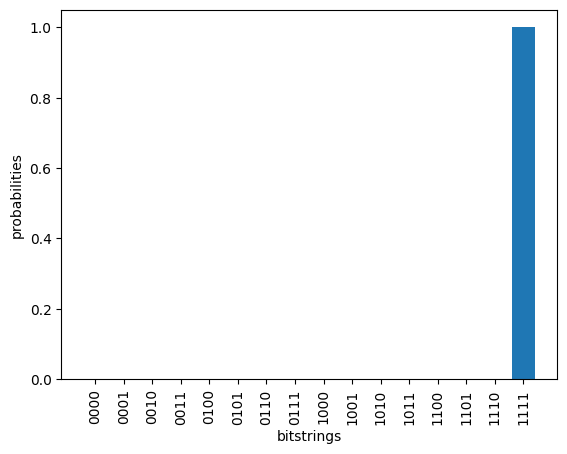

In [13]:
# We can get the results with the variable: dj_probabilities

probabilities = task.result().result_types[0].value
probabilities = np.round(probabilities, 10)  # round off floating-point errors
num_qubits = int(np.log2(len(probabilities)))
binary_strings = [format(i, "b").zfill(num_qubits) for i in range(2**num_qubits)]

dj_probabilities = dict(zip(binary_strings, probabilities))

plot_bitstrings(dj_probabilities)